# Twitter Data Analysis

### Configuração

In [1]:
import os
import sys
import json
import pandas as pd
from dotenv import load_dotenv

sys.path.insert(0, os.path.abspath('..'))

load_dotenv()

from src.api import create_client

client = create_client()
print(f"Provider: {client.provider}")

Provider: getxapi


### Seção 1: Buscar Tweets por Conta

In [2]:
# Busca tweets de um usuário específico
username = 'Barasiil'
tweets = client.get_user_tweets(username, max_results=5, exclude_retweets=True)

print(f"Tweets de @{username}:")
print("-" * 50)
for tweet in tweets:
    print(f"{tweet.created_at}: {tweet.text[:80]}...")
    print()

Tweets de @Barasiil:
--------------------------------------------------
2026-04-19 17:25:29+00:00: EU SOU OBCECADO PELO CONCEITO DA LUCY GRAY...



### Seção 2: Pesquisa Geral (Search)

In [2]:
# Pesquisa tweets por termo/palavra-chave
tweets = client.search("presidente lula", max_results=20)

print(f"Resultados para 'presidente lula': {len(tweets)} tweets")
print("-" * 50)
for tweet in tweets[:5]:
    print(f"{tweet.created_at}: {tweet.text[:80]}...")
    print()

Resultados para 'presidente lula': 20 tweets
--------------------------------------------------
2026-04-19 19:13:58+00:00: Como pode?
E principalmente 
Os mais pobres
Como colegas de trabalho 
Votarem em...

2026-04-19 19:11:35+00:00: LULA um presidente ligado ao Narcotráfico e amigos de Terroristas meus Parabéns ...

2026-04-19 19:09:17+00:00: Durante o CPAC Hungria, o líder espanhol Santiago Abascal intensificou críticas ...

2026-04-19 19:09:03+00:00: @egtegain Sin duda Lula son todo en uno.
Ué vergüenza de Brasil por tener esta b...

2026-04-19 19:08:20+00:00: @DaniloGentili @FlavioBolsonaro Vocês ainda não perceberam que o povo vai votar ...



### Salvar em JSON

In [3]:
tweets_data = [
    {
        'id': t.id,
        'text': t.text,
        'created_at': str(t.created_at),
        'likes': t.likes,
        'retweets': t.retweets
    }
    for t in tweets
]

os.makedirs('../data/raw', exist_ok=True)
with open('../data/raw/tweets.json', 'w', encoding='utf-8') as f:
    json.dump(tweets_data, f, ensure_ascii=False, indent=2)

print(f"Salvos {len(tweets_data)} tweets!")

Salvos 20 tweets!


### Carregar como DataFrame

In [4]:
df = pd.DataFrame(tweets_data)
df

,id,text,created_at,likes,retweets
0,2045944011433693595,Como pode?\nE principalmente \nOs mais pobres\...,2026-04-19 19:13:58+00:00,0,0
1,2045943412067614931,LULA um presidente ligado ao Narcotráfico e am...,2026-04-19 19:11:35+00:00,0,0
2,2045942831978598792,"Durante o CPAC Hungria, o líder espanhol Santi...",2026-04-19 19:09:17+00:00,0,0
3,2045942772453007475,@egtegain Sin duda Lula son todo en uno.\nUé v...,2026-04-19 19:09:03+00:00,0,0
4,2045942594597757067,@DaniloGentili @FlavioBolsonaro Vocês ainda nã...,2026-04-19 19:08:20+00:00,0,0
5,2045942589958901998,ansiosíssimo pra votar ANA PAULA CAMPEÃ e LULA...,2026-04-19 19:08:19+00:00,0,0
6,2045941343050993990,O Presidente Lula promove o Brasil,2026-04-19 19:03:22+00:00,1,1
7,2045941161286897903,Olha o nível desse miserável do Bolsonaro! \n\...,2026-04-19 19:02:39+00:00,0,0
8,2045941142240309457,"📰Em meio à divergência ideológica, Lula diz se...",2026-04-19 19:02:34+00:00,0,0
9,2045940922391707869,🇩🇪 🇧🇷 Presidente Lula chegou na Alemanha como ...,2026-04-19 19:01:42+00:00,0,0


### Seção 3: Análise de Sentimento (NLP)

In [6]:
from src.nlp.preprocessing import get_sentiment
from collections import Counter
import matplotlib.pyplot as plt

# Aplicar sentimento a cada tweet
sentimentos = []
polaridades = []
for t in tweets:
    sent = get_sentiment(t.text)
    sentimentos.append(sent['sentiment'])
    polaridades.append(sent['polarity'])

# Contar sentimentos
contagem = Counter(sentimentos)
print("Contagem de sentimentos:")
for k, v in contagem.items():
    print(f"  {k}: {v}")

# Adicionar ao DataFrame
df['sentiment'] = sentimentos
df['polarity'] = polaridades
df

Contagem de sentimentos:
  neutral: 19
  negative: 1


,id,text,created_at,likes,retweets,sentiment,polarity
0,2045944011433693595,Como pode?\nE principalmente \nOs mais pobres\...,2026-04-19 19:13:58+00:00,0,0,neutral,0.00000
1,2045943412067614931,LULA um presidente ligado ao Narcotráfico e am...,2026-04-19 19:11:35+00:00,0,0,neutral,0.00000
2,2045942831978598792,"Durante o CPAC Hungria, o líder espanhol Santi...",2026-04-19 19:09:17+00:00,0,0,neutral,0.00000
3,2045942772453007475,@egtegain Sin duda Lula son todo en uno.\nUé v...,2026-04-19 19:09:03+00:00,0,0,neutral,0.00000
4,2045942594597757067,@DaniloGentili @FlavioBolsonaro Vocês ainda nã...,2026-04-19 19:08:20+00:00,0,0,neutral,0.00000
5,2045942589958901998,ansiosíssimo pra votar ANA PAULA CAMPEÃ e LULA...,2026-04-19 19:08:19+00:00,0,0,neutral,0.00000
6,2045941343050993990,O Presidente Lula promove o Brasil,2026-04-19 19:03:22+00:00,1,1,neutral,0.00000
7,2045941161286897903,Olha o nível desse miserável do Bolsonaro! \n\...,2026-04-19 19:02:39+00:00,0,0,negative,-0.15625
8,2045941142240309457,"📰Em meio à divergência ideológica, Lula diz se...",2026-04-19 19:02:34+00:00,0,0,neutral,0.00000
9,2045940922391707869,🇩🇪 🇧🇷 Presidente Lula chegou na Alemanha como ...,2026-04-19 19:01:42+00:00,0,0,neutral,0.00000


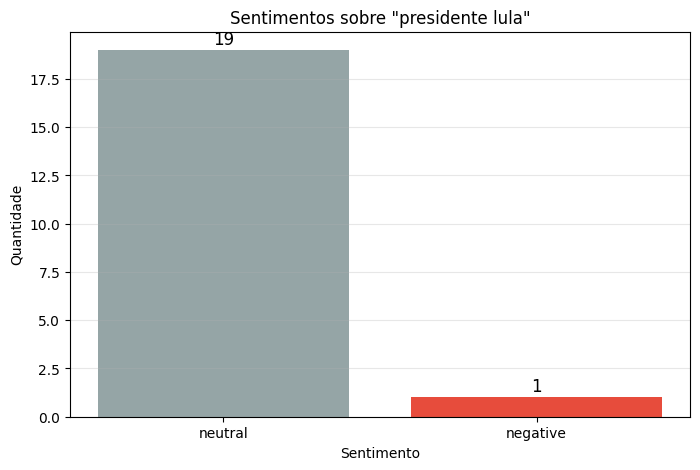

In [7]:
# Gráfico de barras
cores = {'positive': '#2ecc71', 'negative': '#e74c3c', 'neutral': '#95a5a6'}
labels = list(contagem.keys())
valores = list(contagem.values())
cores_barras = [cores.get(l, '#3498db') for l in labels]

plt.figure(figsize=(8, 5))
plt.bar(labels, valores, color=cores_barras)
plt.title('Sentimentos sobre "presidente lula"')
plt.xlabel('Sentimento')
plt.ylabel('Quantidade')
plt.grid(axis='y', alpha=0.3)
for i, v in enumerate(valores):
    plt.text(i, v + 0.3, str(v), ha='center', fontsize=12)
plt.show()